# 10 — Scenario-Based Monte Carlo Simulation

## Main question

**How can the calibrated wildlife-strike probability systems be converted into reproducible distributions of plausible aircraft consequences, and how do those distributions change when one scenario condition is varied while the remaining conditions are controlled?**

This notebook implements the simulation layer and **does not retrain** any predictive model. It consumes the approved final probability systems and repeatedly samples from their probabilities.

The simulation is conditional on a wildlife strike:

$$
P(\text{consequence}\mid \text{wildlife-strike scenario})
$$

It does **not** estimate the probability that an ordinary flight experiences a wildlife strike and it is **not** a collision-physics or structural-damage simulator.

### Simulation chain

$$
X \rightarrow \hat p_D \rightarrow D\sim\mathrm{Bernoulli}(\hat p_D)
$$

When $D=1$, the approved conditional severity and component systems are evaluated.

### Decisions carried forward

- The calibrated binary damage model is the primary simulation backbone.
- Probabilities are sampled directly; classification thresholds are not Monte Carlo decision rules.
- The default is **10,000 trials**, subject to convergence/runtime verification.
- Scenarios support fully specified inputs and hybrid user inputs with empirical filling.
- Required user-facing domains are geography, aircraft, season, and phase of flight.
- Wildlife can be user-selected or sampled from compatible historical strikes when omitted.
- Severity uses only the approved simplified known-severity system.
- Only component models promoted for downstream use are included.
- Joint component interpretation remains cautious because component models were fitted separately.

## 1. Hybrid scenario design

The default practitioner-facing scenario requires:

| Domain | Required input |
|---|---|
| Geography | `AIRPORT_ID` **or** `FAAREGION` |
| Aircraft | `AC_CLASS`, `AC_MASS_GROUP` |
| Time | `SEASON` |
| Flight condition | `PHASE_OF_FLIGHT` |

Optional inputs include wildlife type/size/number struck, engine characteristics, warning status, height, speed, time of day, sky, precipitation and state.

When optional fields are left blank, they are filled from historically compatible **whole donor rows**. This preserves observed relationships among unspecified variables better than sampling every field independently.

A region-level scenario represents a historical mixture of airports within that FAA region. An airport-level scenario keeps the airport fixed.

In [1]:
from pathlib import Path
import json, math, time, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

pd.set_option("display.max_columns", 160)
SEED = 42
DEFAULT_TRIALS = 10_000

## 2. Portable repository paths

The notebook searches upward from the current working directory for the project root. It expects the approved artifacts under `models/final/06_calibration_validation/`, `models/final/07_severity_modelling/`, and `models/final/08_component_modelling/` and writes simulation outputs to `outputs/10_simulation_analysis/`.

In [2]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() and (candidate / "models").exists():
        ROOT = candidate
        break

DATA_CANDIDATES = [
    ROOT / "data" / "processed" / "faa_strikes_analytical.csv",
    ROOT / "data" / "faa_strikes_analytical.csv",
    ROOT / "faa_strikes_analytical.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])
FINAL_06 = ROOT / "models" / "final" / "06_calibration_validation"
FINAL_07 = ROOT / "models" / "final" / "07_severity_modelling"
FINAL_08 = ROOT / "models" / "final" / "08_component_modelling"
OUTPUT_DIR = ROOT / "outputs" / "10_simulation_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BINARY_MODEL_PATH = FINAL_06 / "final_calibrated_pipeline.joblib"
SEVERITY_MODEL_PATH = FINAL_07 / "final_known_severity_probability_system.joblib"
COMPONENT_MODEL_PATHS = {
    "ENGINE_DAMAGE": FINAL_08 / "engine_damage_component_probability_system.joblib",
    "FORWARD_COCKPIT_DAMAGE": FINAL_08 / "forward_cockpit_damage_component_probability_system.joblib",
    "LANDING_GEAR_DAMAGE": FINAL_08 / "landing_gear_damage_component_probability_system.joblib",
    "PROPELLER_DAMAGE": FINAL_08 / "propeller_damage_component_probability_system.joblib",
    "WING_ROTOR_DAMAGE": FINAL_08 / "wing_rotor_damage_component_probability_system.joblib",
}
print("ROOT:", ROOT)
print("DATA:", DATA_PATH)
print("OUTPUT:", OUTPUT_DIR)

ROOT: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
DATA: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
OUTPUT: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\10_simulation_analysis


### Serialization compatibility

Some approved component artifacts contain a small custom calibration wrapper. The class below is reproduced **only to deserialize the already-fitted object**. It does not retrain or replace any upstream model.

If package-version warnings prevent prediction, reproduce the modelling environment rather than rebuilding a replacement model inside Notebook 10.

In [3]:
class BinaryProbabilityCalibrator:
    def __init__(self, method="sigmoid"):
        self.method = method
        self.model = None
    def fit(self, raw_probabilities, y):
        p = np.asarray(raw_probabilities, dtype=float)
        y = np.asarray(y, dtype=int)
        if self.method == "sigmoid":
            self.model = LogisticRegression(solver="lbfgs", random_state=SEED)
            self.model.fit(p.reshape(-1, 1), y)
        else:
            self.model = IsotonicRegression(out_of_bounds="clip")
            self.model.fit(p, y)
        return self
    def predict(self, raw_probabilities):
        p = np.asarray(raw_probabilities, dtype=float)
        if self.method == "sigmoid":
            return self.model.predict_proba(p.reshape(-1, 1))[:, 1]
        return np.asarray(self.model.predict(p), dtype=float)

In [4]:
required_files = [DATA_PATH, BINARY_MODEL_PATH, SEVERITY_MODEL_PATH, *COMPONENT_MODEL_PATHS.values()]
missing = [p for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required upstream artifacts:\n" + "\n".join(map(str, missing)))

df = pd.read_csv(DATA_PATH, low_memory=False)
damage_model = joblib.load(BINARY_MODEL_PATH)
severity_system = joblib.load(SEVERITY_MODEL_PATH)
component_systems = {k: joblib.load(v) for k, v in COMPONENT_MODEL_PATHS.items()}
print("Rows:", f"{len(df):,}")
print("Years:", int(df["INCIDENT_YEAR"].min()), "-", int(df["INCIDENT_YEAR"].max()))

Rows: 319,107
Years: 1990 - 2024


## 3. Downstream decision gates

The approved severity artifact is the simplified known-severity formulation:

$$
P(S{+}D \mid D=1,\ \text{severity known}, X)
$$

where class 0 is Minor (`M`) and class 1 is Substantial/Destroyed (`S+D`). `M?` remains excluded because it represents undetermined severity.

Each retained component system estimates:

$$
P(C_j=1\mid D=1,X)
$$

and is used only if its stored decision is `MODELLED`.

In [5]:
assert severity_system.get("decision") in {"RETAIN", "SIMPLIFY"}
for target, system in component_systems.items():
    assert system.get("decision") == "MODELLED", f"{target} not approved"
    assert system.get("population_condition") == "INDICATED_DAMAGE == 1"

display(pd.Series({
    "decision": severity_system.get("decision"),
    "target_definition": severity_system.get("target_definition"),
    "conditioning": severity_system.get("conditioning"),
    "excluded_category": severity_system.get("excluded_severity_category"),
}, name="severity"))

display(pd.DataFrame([{
    "target": t,
    "family": s.get("model_family"),
    "feature_set": s.get("feature_set"),
    "calibration": s.get("calibration_method"),
    "test_pr_auc": s.get("final_test_evidence_summary", {}).get("pr_auc"),
    "test_prevalence": s.get("final_test_evidence_summary", {}).get("test_prevalence"),
    "support_note": s.get("support_note"),
} for t, s in component_systems.items()]))

decision                                                      SIMPLIFY
target_definition                               {'0': 'M', '1': 'S+D'}
conditioning         Conditional on reported strike, aircraft damag...
excluded_category                                                   M?
Name: severity, dtype: object

,target,family,feature_set,calibration,test_pr_auc,test_prevalence,support_note
0,ENGINE_DAMAGE,xgboost,extended_geographic,isotonic,0.437,0.204,Substantial component support. The target pool...
1,FORWARD_COCKPIT_DAMAGE,xgboost,extended_geographic,sigmoid,0.461,0.239,"This is a pooled outcome combining DAM_RAD, DA..."
2,LANDING_GEAR_DAMAGE,random_forest,airport_aware,raw,0.248,0.040,Lower-prevalence outcome. Retained because fut...
3,PROPELLER_DAMAGE,xgboost,airport_aware,isotonic,0.272,0.023,LOW-SUPPORT WARNING: retained because discrimi...
4,WING_ROTOR_DAMAGE,random_forest,extended_geographic,sigmoid,0.573,0.335,Strong component support relative to the other...


### Interpretation

All approved downstream artifacts loaded successfully. The severity system records a `SIMPLIFY` decision and therefore contributes only the known-severity binary formulation, distinguishing Minor (`M`) from Substantial/Destroyed (`S+D`) among damaged incidents with determined severity. The `M?` category remains excluded from this downstream probability system because it represents undetermined severity rather than an ordered physical severity level.

All five supplied component systems also passed their stored downstream decision gates: engine, forward cockpit, landing gear, propeller, and wing/rotor damage. Their locked test PR-AUC values were approximately 0.437, 0.461, 0.248, 0.272, and 0.573 respectively, showing that predictive strength differs across component outcomes. Propeller damage remains subject to an explicit lower-support warning because its final-test prevalence was only about 2.3%.

No model was retrained in this notebook. Stored classification thresholds remain reporting references only and are not used to generate Monte Carlo outcomes; the simulation samples directly from the fitted probability estimates.

## 4. Canonical feature contract

The final calibrated binary pipeline defines the primary model inputs. The simulation passes those columns to the saved pipeline so the exact fitted preprocessing is reused.

In [6]:
DAMAGE_FEATURES = list(getattr(damage_model, "feature_names_in_", []))
if not DAMAGE_FEATURES:
    raise RuntimeError("No feature_names_in_; load the Notebook 06 feature manifest.")
assert not [c for c in DAMAGE_FEATURES if c not in df.columns]
print("Final binary feature count:", len(DAMAGE_FEATURES))
display(pd.DataFrame({"feature": DAMAGE_FEATURES}))

Final binary feature count: 20


,feature
0,SEASON
1,MONTH_SIN
2,MONTH_COS
3,WILDLIFE_TYPE
4,SIZE
5,NUM_STRUCK
6,AC_CLASS
7,AC_MASS_GROUP
8,TYPE_ENG
9,NUM_ENGS


## 5. Development/reference and held-out periods

Empirical donor sampling and support calculations use 1990–2021 so the locked 2022–2024 period remains untouched until validation:

$$
\mathcal H_{dev}=1990\text{--}2021,\qquad \mathcal H_{test}=2022\text{--}2024.
$$

The current extract is inspected for its true maximum year; no 2025+ data are assumed.

In [7]:
DEV_REFERENCE_END_YEAR = 2021
TEST_START_YEAR, TEST_END_YEAR = 2022, 2024
dev_reference = df.loc[df["INCIDENT_YEAR"].le(DEV_REFERENCE_END_YEAR)].copy()
heldout = df.loc[df["INCIDENT_YEAR"].between(TEST_START_YEAR, TEST_END_YEAR)].copy()
print("Development/reference rows:", f"{len(dev_reference):,}")
print("Held-out rows:", f"{len(heldout):,}")
print("Maximum available year:", int(df["INCIDENT_YEAR"].max()))

Development/reference rows: 259,888
Held-out rows: 59,219
Maximum available year: 2024


## 6. Scenario schema and support

A scenario requires aircraft class/mass, season, phase, and either an airport or FAA region. Wildlife and other context can remain optional.

Historical support is reported separately from the predicted probability. Zero-support required combinations are blocked by default rather than presented with false numerical precision.

In [8]:
REQUIRED_USER_FIELDS = ["AC_CLASS", "AC_MASS_GROUP", "SEASON", "PHASE_OF_FLIGHT"]
GEOGRAPHY_FIELDS = ["AIRPORT_ID", "FAAREGION"]
OPTIONAL_USER_FIELDS = [
    "WILDLIFE_TYPE", "SIZE", "NUM_STRUCK", "TYPE_ENG", "NUM_ENGS", "WARNED",
    "HEIGHT", "SPEED", "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE"
]

def validate_scenario(scenario, reference_df=dev_reference):
    scenario = {k:v for k,v in scenario.items() if v is not None}
    missing = [f for f in REQUIRED_USER_FIELDS if f not in scenario]
    if missing: raise ValueError(f"Missing required fields: {missing}")
    if not any(g in scenario for g in GEOGRAPHY_FIELDS):
        raise ValueError("Provide AIRPORT_ID or FAAREGION")
    unknown = {}
    for field, value in scenario.items():
        if field in reference_df.columns:
            vals = set(reference_df[field].dropna().astype(str).unique())
            if str(value) not in vals: unknown[field] = value
    if unknown: raise ValueError(f"Unseen values: {unknown}")

def exact_support_count(scenario, reference_df=dev_reference):
    mask = pd.Series(True, index=reference_df.index)
    for field, value in scenario.items():
        if value is not None and field in reference_df.columns:
            mask &= reference_df[field].astype(str).eq(str(value))
    return int(mask.sum())

## 7. Conditional empirical sampling

Whole historical donor rows are sampled to preserve the empirical joint structure of unspecified variables. If the exact user specification has few donors, the **donor search only** may be broadened in a documented hierarchy while every explicit user value is re-applied to the simulated rows.

In [9]:
PREFERRED_DONOR_ROWS = 100

def _filter(frame, conditions):
    mask = pd.Series(True, index=frame.index)
    for f,v in conditions.items():
        if v is not None and f in frame.columns:
            mask &= frame[f].astype(str).eq(str(v))
    return frame.loc[mask]

def donor_pool_for_scenario(scenario, reference_df=dev_reference):
    scenario = {k:v for k,v in scenario.items() if v is not None}
    validate_scenario(scenario, reference_df)
    exact_n = exact_support_count(scenario, reference_df)
    if exact_n == 0: raise ValueError("Zero exact historical support; blocked.")
    attempts = [("exact_user_specification", dict(scenario))]
    if "AIRPORT_ID" in scenario:
        hist = reference_df.loc[reference_df["AIRPORT_ID"].astype(str).eq(str(scenario["AIRPORT_ID"]))]
        mode = hist["FAAREGION"].dropna().mode()
        if len(mode):
            x = dict(scenario); x.pop("AIRPORT_ID", None); x["FAAREGION"] = mode.iloc[0]
            attempts.append(("airport_to_region_for_donors", x))
    core = {k:v for k,v in scenario.items() if k in REQUIRED_USER_FIELDS or k in GEOGRAPHY_FIELDS}
    attempts.append(("required_fields_only", core))
    geo_ac = {k:v for k,v in scenario.items() if k in GEOGRAPHY_FIELDS or k in {"AC_CLASS","AC_MASS_GROUP"}}
    attempts.append(("geography_plus_aircraft", geo_ac))
    chosen = None
    for name, cond in attempts:
        pool = _filter(reference_df, cond); chosen = (name, cond, pool)
        if len(pool) >= PREFERRED_DONOR_ROWS: break
    name, cond, pool = chosen
    return {"pool":pool.copy(), "strategy":name, "exact_support":exact_n,
            "donor_support":len(pool), "relaxed":name!="exact_user_specification"}

def build_simulation_rows(scenario, n_trials=DEFAULT_TRIALS, seed=SEED, reference_df=dev_reference):
    info = donor_pool_for_scenario(scenario, reference_df)
    rng = np.random.default_rng(seed)
    idx = rng.choice(info["pool"].index.to_numpy(), size=n_trials, replace=True)
    sim = reference_df.loc[idx, DAMAGE_FEATURES].reset_index(drop=True).copy()
    for f,v in scenario.items():
        if v is not None and f in sim.columns: sim[f] = v
    if "AIRPORT_ID" in scenario:
        hist = reference_df.loc[reference_df["AIRPORT_ID"].astype(str).eq(str(scenario["AIRPORT_ID"]))]
        for f in ["STATE","FAAREGION"]:
            if f not in scenario and f in sim.columns:
                mode = hist[f].dropna().mode()
                if len(mode): sim[f] = mode.iloc[0]
    return sim, {k:info[k] for k in ["strategy","exact_support","donor_support","relaxed"]}

## 8. Monte Carlo mechanics

For trial $i$, the calibrated model provides:

$$
\hat p_{D,i}=P(D_i=1\mid X_i,\text{strike})
$$

and the simulation draws:

$$
D_i\sim \mathrm{Bernoulli}(\hat p_{D,i}).
$$

A fully specified scenario can have one common probability across trials; a hybrid scenario can have a distribution of probabilities because unspecified context varies.

In [10]:
def secondary_probability(system, X):
    raw = system["base_pipeline"].predict_proba(X[system["features"]])[:,1]
    cal = system.get("calibrator")
    return raw if cal is None else cal.predict(raw)

def run_monte_carlo(scenario, n_trials=DEFAULT_TRIALS, seed=SEED,
                    include_severity=True, include_components=True):
    X, support = build_simulation_rows(scenario, n_trials, seed)
    rng = np.random.default_rng(seed)
    p_damage = damage_model.predict_proba(X[DAMAGE_FEATURES])[:,1]
    damage = rng.binomial(1, p_damage)
    res = X.copy(); res.insert(0,"trial",np.arange(n_trials))
    res["p_damage"] = p_damage; res["damage"] = damage
    damaged = res["damage"].eq(1)
    res["p_substantial_or_destroyed_given_known"] = np.nan
    res["severity_known_draw"] = pd.NA
    if include_severity and damaged.any():
        p = secondary_probability(severity_system, X.loc[damaged])
        y = rng.binomial(1,p)
        res.loc[damaged,"p_substantial_or_destroyed_given_known"] = p
        res.loc[damaged,"severity_known_draw"] = np.where(y==1,"S+D","M")
    if include_components and damaged.any():
        for target, system in component_systems.items():
            p = secondary_probability(system, X.loc[damaged])
            y = rng.binomial(1,p)
            res["p_"+target.lower()] = np.nan; res[target.lower()] = 0
            res.loc[damaged,"p_"+target.lower()] = p
            res.loc[damaged,target.lower()] = y
    rate = float(res["damage"].mean())
    summary = {"scenario":scenario,"n_trials":n_trials,"seed":seed,
               "damage_probability_mean":float(p_damage.mean()),
               "simulated_damage_rate":rate,
               "mc_standard_error":float(math.sqrt(max(rate*(1-rate),0)/n_trials)),
               "n_damaged_trials":int(damaged.sum()),"support":support}
    return res, summary

## 9. Reproducible demonstration scenario

The demonstration uses a common required-field combination from the development/reference population instead of inventing a scenario with unknown support.

In [11]:
cols = ["AIRPORT_ID","AC_CLASS","AC_MASS_GROUP","SEASON","PHASE_OF_FLIGHT"]
scenario_counts = dev_reference.dropna(subset=cols).groupby(cols, observed=True).size().sort_values(ascending=False).rename("historical_support").reset_index()
display(scenario_counts.head(10))

# Prefer a presentation-ready scenario:
# known airport, reported aircraft fields, and reported flight phase.
presentation_candidates = scenario_counts.loc[
    ~scenario_counts["AIRPORT_ID"].astype(str).isin(["ZZZZ", "Not reported", "Unknown"])
    & ~scenario_counts["AC_CLASS"].astype(str).isin(["Not reported", "Unknown"])
    & ~scenario_counts["AC_MASS_GROUP"].astype(str).isin(["Not reported", "Unknown"])
    & ~scenario_counts["PHASE_OF_FLIGHT"].astype(str).isin(["Not reported", "Unknown"])
].copy()

display(presentation_candidates.head(10))

top = presentation_candidates.iloc[0]
EXAMPLE_SCENARIO = {c:top[c] for c in cols}
print(json.dumps(EXAMPLE_SCENARIO, indent=2, default=str))
print("Historical support:", int(top["historical_support"]))

t0=time.perf_counter(); example_trials, example_summary=run_monte_carlo(EXAMPLE_SCENARIO)
example_summary["runtime_seconds"] = time.perf_counter()-t0
display(pd.Series(example_summary))

,AIRPORT_ID,AC_CLASS,AC_MASS_GROUP,SEASON,PHASE_OF_FLIGHT,historical_support
0,ZZZZ,A,Heavy,Autumn,Not reported,9439
1,ZZZZ,A,Heavy,Spring,Not reported,5909
2,ZZZZ,A,Heavy,Summer,Not reported,5370
3,KDEN,Not reported,Unknown,Summer,Not reported,2275
4,ZZZZ,A,Heavy,Winter,Not reported,1700
5,ZZZZ,A,Medium,Autumn,Not reported,1224
6,KJFK,Not reported,Unknown,Summer,Not reported,1213
7,KDFW,Not reported,Unknown,Summer,Not reported,1156
8,ZZZZ,B,Light,Autumn,En Route,1116
9,KMEM,A,Heavy,Autumn,Approach,1053


,AIRPORT_ID,AC_CLASS,AC_MASS_GROUP,SEASON,PHASE_OF_FLIGHT,historical_support
9,KMEM,A,Heavy,Autumn,Approach,1053
15,KMEM,A,Heavy,Spring,Approach,848
16,KSDF,A,Heavy,Autumn,Approach,761
19,KEWR,A,Heavy,Autumn,Approach,731
22,KLGA,A,Heavy,Autumn,Approach,677
26,KJFK,A,Heavy,Autumn,Approach,598
28,KDEN,A,Heavy,Summer,Landing Roll,549
29,KCLT,A,Heavy,Autumn,Approach,541
30,KDEN,A,Heavy,Summer,Take-off Run,530
34,KDFW,A,Heavy,Autumn,Approach,504


{
  "AIRPORT_ID": "KMEM",
  "AC_CLASS": "A",
  "AC_MASS_GROUP": "Heavy",
  "SEASON": "Autumn",
  "PHASE_OF_FLIGHT": "Approach"
}
Historical support: 1053


scenario                   {'AIRPORT_ID': 'KMEM', 'AC_CLASS': 'A', 'AC_MA...
n_trials                                                               10000
seed                                                                      42
damage_probability_mean                                             0.028596
simulated_damage_rate                                                 0.0291
mc_standard_error                                                   0.001681
n_damaged_trials                                                         291
support                    {'strategy': 'exact_user_specification', 'exac...
runtime_seconds                                                     1.057647
dtype: object

### Interpreation

The presentation scenario selected from the development/reference population represents a heavy Class A aircraft at Memphis International Airport (KMEM) during Autumn and in the Approach phase of flight. This combination has 1,053 exact historical records in the 1990–2021 reference period, so it is classified as strongly supported and does not require donor relaxation.

Under the hybrid scenario specification, the fitted model produced a mean calibrated aircraft-damage probability of approximately 2.86%. Across 10,000 Monte Carlo trials, 2.91% of simulated strikes resulted in aircraft damage. The close agreement between the mean model probability and the simulated damage rate is expected because the Bernoulli draws are sampling directly from those fitted probabilities. The small difference reflects ordinary Monte Carlo sampling variability rather than a separate model discrepancy.

## 10. Why 10,000 trials is the default

Unlike hyperparameter tuning, this stage does not repeatedly fit Random Forests or other candidates. It performs batched inference through already-fitted models and random draws.

For a Bernoulli proportion:

$$
SE_{MC}(\hat p)\approx\sqrt{\frac{\hat p(1-\hat p)}{N}}.
$$

At worst-case $p=0.5$, $N=10{,}000$ gives approximately 0.005 Monte Carlo standard error. The actual convergence experiment below determines whether a lower count would be adequate.

,mean_rate,sd_across_seeds,mean_runtime
n_trials,,,
100,0.02800,0.016432,0.546496
500,0.02600,0.008602,0.568039
1000,0.02880,0.007887,0.591138
2500,0.02680,0.003868,0.605004
5000,0.02696,0.003951,0.666667
10000,0.02786,0.001763,0.715936


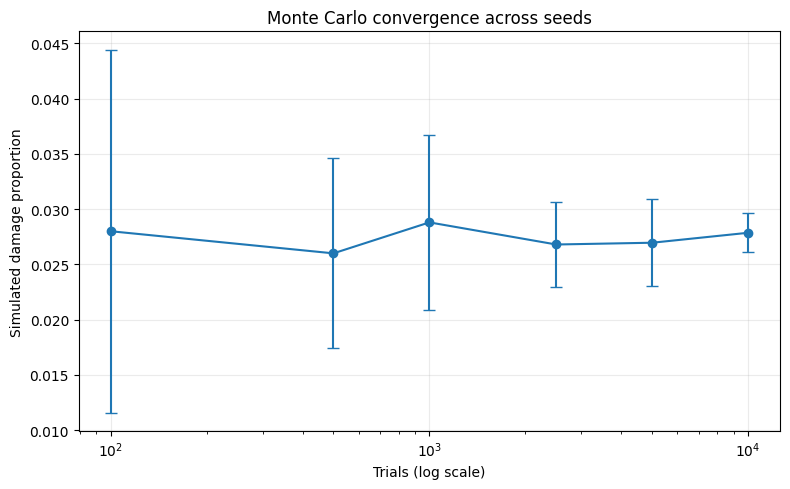

In [12]:
COUNTS=[100,500,1000,2500,5000,10000]; SEEDS=[11,42,101,2026,9001]; rows=[]
for n in COUNTS:
    for seed in SEEDS:
        t0=time.perf_counter(); _,s=run_monte_carlo(EXAMPLE_SCENARIO,n,seed,False,False)
        rows.append({"n_trials":n,"seed":seed,"damage_rate":s["simulated_damage_rate"],
                     "mean_probability":s["damage_probability_mean"],"runtime":time.perf_counter()-t0})
convergence=pd.DataFrame(rows)
display(convergence.groupby("n_trials").agg(mean_rate=("damage_rate","mean"),sd_across_seeds=("damage_rate","std"),mean_runtime=("runtime","mean")))
convergence.to_csv(OUTPUT_DIR/"monte_carlo_convergence.csv",index=False)

conv=convergence.groupby("n_trials")["damage_rate"].agg(["mean","std"]).reset_index()
fig,ax=plt.subplots(figsize=(8,5)); ax.errorbar(conv["n_trials"],conv["mean"],yerr=conv["std"],marker="o",capsize=4)
ax.set_xscale("log"); ax.set_xlabel("Trials (log scale)"); ax.set_ylabel("Simulated damage proportion"); ax.set_title("Monte Carlo convergence across seeds"); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

### Convergence interpretation placeholder

Monte Carlo stability improved as the number of trials increased. Across five random seeds, the standard deviation of the simulated damage rate decreased from approximately 0.0164 at 100 trials to 0.00176 at 10,000 trials. The mean simulated damage rate at 10,000 trials was approximately 2.79%, close to the model-implied probability for the scenario and substantially more stable than the lower-trial alternatives.

Computational cost remained low: the mean runtime for the 10,000-trial binary simulation was approximately 0.72 seconds, while the complete demonstration including severity and component layers required only about 1.06 seconds. Therefore, 10,000 trials remain an appropriate default for both analytical use and the planned Streamlit interface. This is considerably less computationally demanding than model tuning because the fitted models are reused rather than repeatedly trained.

## 11. Aggregate consequence summary

,outcome,rate,population
0,Damage,0.029100,all simulated strikes
1,No damage,0.970900,all simulated strikes
2,Known severity: M,0.769759,simulated damaged strikes
3,Known severity: S+D,0.230241,simulated damaged strikes
4,ENGINE_DAMAGE,0.096220,simulated damaged strikes
5,FORWARD_COCKPIT_DAMAGE,0.333333,simulated damaged strikes
6,LANDING_GEAR_DAMAGE,0.024055,simulated damaged strikes
7,PROPELLER_DAMAGE,0.000000,simulated damaged strikes
8,WING_ROTOR_DAMAGE,0.257732,simulated damaged strikes


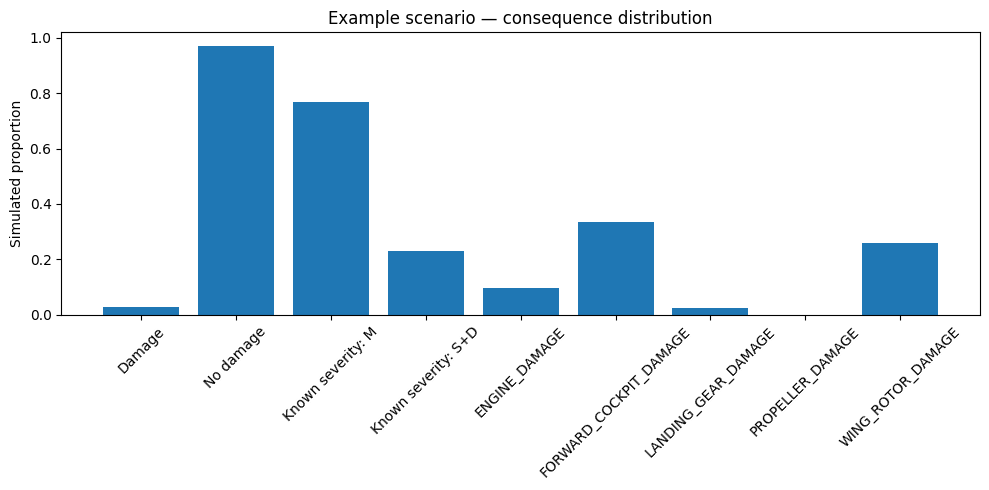

In [13]:
def summarize_simulation(results):
    rows=[{"outcome":"Damage","rate":results["damage"].mean(),"population":"all simulated strikes"},
          {"outcome":"No damage","rate":1-results["damage"].mean(),"population":"all simulated strikes"}]
    d=results.loc[results["damage"].eq(1)]
    if len(d):
        for lab,rate in d["severity_known_draw"].value_counts(normalize=True).items():
            rows.append({"outcome":"Known severity: "+str(lab),"rate":rate,"population":"simulated damaged strikes"})
        for target in component_systems:
            rows.append({"outcome":target,"rate":d[target.lower()].mean(),"population":"simulated damaged strikes"})
    return pd.DataFrame(rows)
example_outcomes=summarize_simulation(example_trials); display(example_outcomes)
example_outcomes.to_csv(OUTPUT_DIR/"example_scenario_outcomes.csv",index=False)
fig,ax=plt.subplots(figsize=(10,5)); ax.bar(example_outcomes["outcome"],example_outcomes["rate"]); ax.set_ylabel("Simulated proportion"); ax.set_title("Example scenario — consequence distribution"); ax.tick_params(axis="x",rotation=45); plt.tight_layout(); plt.show()

## 12. Component co-occurrence before joint interpretation

Observed pairwise component dependence is assessed among damaged incidents. For binary variables the Pearson correlation equals the $\phi$ coefficient. This is an association measure, **not evidence that damage in one component causes damage in another**.

The simulator retains component marginals from the approved models. Exact multi-component bundles are treated as approximate unless simulated and observed co-occurrence agree adequately.

,ENGINE_DAMAGE,FORWARD_COCKPIT_DAMAGE,LANDING_GEAR_DAMAGE,PROPELLER_DAMAGE,WING_ROTOR_DAMAGE
ENGINE_DAMAGE,1.000,-0.274,-0.076,0.019,-0.315
FORWARD_COCKPIT_DAMAGE,-0.274,1.000,-0.067,-0.019,-0.265
LANDING_GEAR_DAMAGE,-0.076,-0.067,1.000,0.158,-0.042
PROPELLER_DAMAGE,0.019,-0.019,0.158,1.000,-0.027
WING_ROTOR_DAMAGE,-0.315,-0.265,-0.042,-0.027,1.000


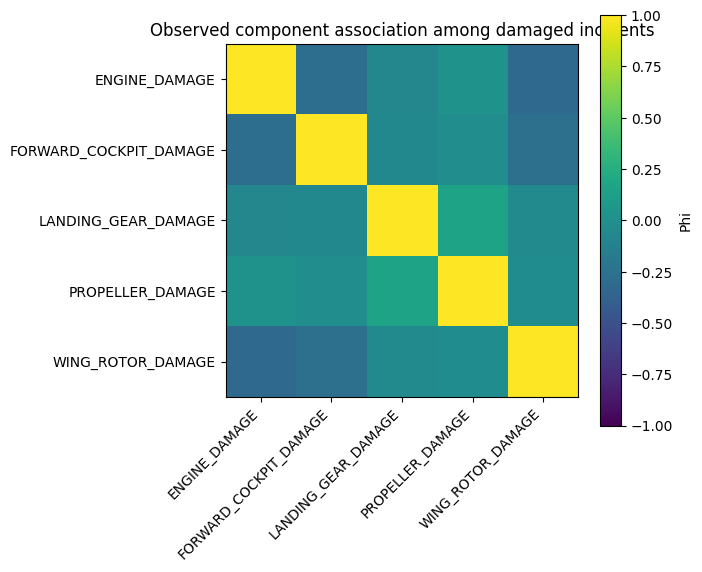

,ENGINE_DAMAGE,FORWARD_COCKPIT_DAMAGE,LANDING_GEAR_DAMAGE,PROPELLER_DAMAGE,WING_ROTOR_DAMAGE
ENGINE_DAMAGE,1.000,-0.008,-0.051,NaN,0.101
FORWARD_COCKPIT_DAMAGE,-0.008,1.000,-0.016,NaN,0.067
LANDING_GEAR_DAMAGE,-0.051,-0.016,1.000,NaN,-0.041
PROPELLER_DAMAGE,NaN,NaN,NaN,NaN,NaN
WING_ROTOR_DAMAGE,0.101,0.067,-0.041,NaN,1.000


observed_mean_absolute_pairwise_phi     0.126354
simulated_mean_absolute_pairwise_phi    0.047338
observed_max_absolute_pairwise_phi      0.315411
simulated_max_absolute_pairwise_phi     0.100803
dtype: float64

In [14]:
def derive_components(frame):
    out=pd.DataFrame(index=frame.index)
    out["ENGINE_DAMAGE"]=frame[["DAM_ENG1","DAM_ENG2","DAM_ENG3","DAM_ENG4"]].fillna(False).astype(bool).any(axis=1).astype(int)
    out["FORWARD_COCKPIT_DAMAGE"]=frame[["DAM_RAD","DAM_WINDSHLD","DAM_NOSE"]].fillna(False).astype(bool).any(axis=1).astype(int)
    out["LANDING_GEAR_DAMAGE"]=frame["DAM_LG"].fillna(False).astype(bool).astype(int)
    out["PROPELLER_DAMAGE"]=frame["DAM_PROP"].fillna(False).astype(bool).astype(int)
    out["WING_ROTOR_DAMAGE"]=frame["DAM_WING_ROT"].fillna(False).astype(bool).astype(int)
    return out
obs=derive_components(dev_reference.loc[dev_reference["INDICATED_DAMAGE"].eq(1)]); observed_phi=obs.corr(); display(observed_phi.round(3)); observed_phi.to_csv(OUTPUT_DIR/"observed_component_phi.csv")
fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(observed_phi.to_numpy(),vmin=-1,vmax=1); ax.set_xticks(range(len(observed_phi.columns)),observed_phi.columns,rotation=45,ha="right"); ax.set_yticks(range(len(observed_phi.index)),observed_phi.index); ax.set_title("Observed component association among damaged incidents"); fig.colorbar(im,ax=ax,label="Phi"); plt.tight_layout(); plt.show()

sim_d=example_trials.loc[example_trials["damage"].eq(1)]; sim_cols=[t.lower() for t in component_systems]; sim_phi=sim_d[sim_cols].corr(); sim_phi.index=[x.upper() for x in sim_phi.index]; sim_phi.columns=[x.upper() for x in sim_phi.columns]; display(sim_phi.round(3)); sim_phi.to_csv(OUTPUT_DIR/"simulated_component_phi_example.csv")

observed_offdiag = observed_phi.copy()
np.fill_diagonal(observed_offdiag.values, np.nan)

sim_offdiag = sim_phi.copy()
np.fill_diagonal(sim_offdiag.values, np.nan)

component_dependence_summary = pd.Series({
    "observed_mean_absolute_pairwise_phi":
        np.nanmean(np.abs(observed_offdiag.to_numpy())),
    "simulated_mean_absolute_pairwise_phi":
        np.nanmean(np.abs(sim_offdiag.to_numpy())),
    "observed_max_absolute_pairwise_phi":
        np.nanmax(np.abs(observed_offdiag.to_numpy())),
    "simulated_max_absolute_pairwise_phi":
        np.nanmax(np.abs(sim_offdiag.to_numpy())),
})

display(component_dependence_summary)
component_dependence_summary.to_csv(
    OUTPUT_DIR / "component_dependence_summary.csv"
)


### Co-occurrence interpretation

The observed damaged-strike data show meaningful pairwise association among several component outcomes. The strongest observed relationships were negative associations between engine and wing/rotor damage $(ϕ≈−0.315)$, engine and forward-cockpit damage $(ϕ≈−0.274)$, and forward-cockpit and wing/rotor damage $(ϕ≈−0.265)$. Landing-gear and propeller damage showed a smaller positive association of approximately 0.158. These values represent statistical co-occurrence patterns and must not be interpreted as physical or causal propagation between components.

The independent Bernoulli simulation reproduced substantially less component dependence. Mean absolute pairwise $ϕ$ decreased from approximately 0.126 in the observed data to 0.047 in the simulated outcomes, while the maximum absolute association decreased from approximately 0.315 to 0.101. This is consistent with the modelling design because the component probability systems were fitted independently rather than as a joint multivariate damage model.

Consequently, the most defensible downstream presentation is to report the five approved component probabilities as marginal conditional consequences. Exact multi-component bundles may be used only as exploratory illustrations and should not be presented as validated physical damage pathways. The absence of simulated propeller damage in this particular scenario should likewise not be interpreted as zero real-world possibility, especially given the component model's lower-support warning. The upstream component design explicitly cautions that independently fitted models do not constitute a full dependence or physical-propagation model.

## 13. Controlled one-variable comparisons

A controlled comparison changes one input while all other specified conditions remain constant:

$$
\Delta\hat p=\hat p_D(x')-\hat p_D(x).
$$

This is a model-based contrast, not a causal treatment effect. The same random seed is used across alternatives to reduce irrelevant simulation noise.

,field,value,mean_probability,simulated_rate,exact_support,common_donor_support,common_donor_strategy,status,delta_vs_first
0,SIZE,Small,0.007984,0.0083,417,1053,exact_user_specification,OK,0.000000
1,SIZE,Medium,0.037774,0.0347,456,1053,exact_user_specification,OK,0.029790
2,SIZE,Large,0.154503,0.1601,48,1053,exact_user_specification,OK,0.146519


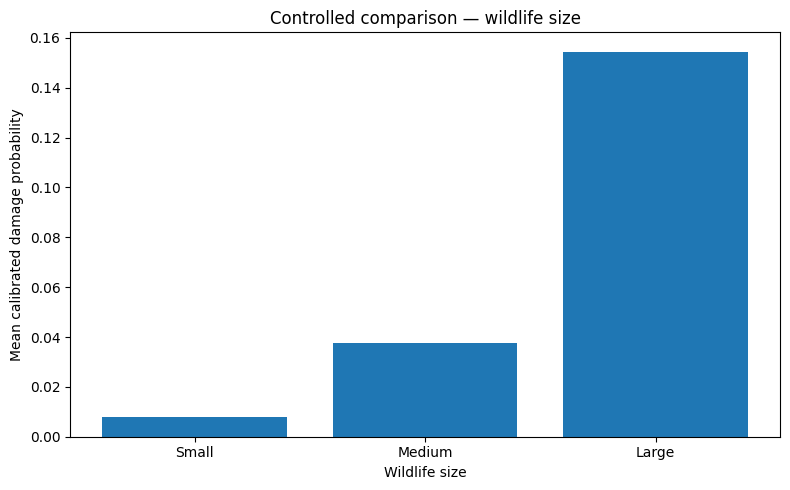

In [15]:
def compare_one_factor(base, field, values, n_trials=DEFAULT_TRIALS, seed=SEED):
    """
    Controlled comparison using one common donor sample and common random numbers.
    Only the comparison field changes across alternatives.
    """
    base_without_field = {k:v for k,v in base.items() if k != field}

    X_base, base_support = build_simulation_rows(
        base_without_field,
        n_trials=n_trials,
        seed=seed
    )

    rng = np.random.default_rng(seed)
    common_uniforms = rng.random(n_trials)

    rows = []

    for value in values:
        X = X_base.copy()
        X[field] = value

        p = damage_model.predict_proba(X[DAMAGE_FEATURES])[:, 1]
        simulated_damage = (common_uniforms < p).astype(int)

        scenario_with_value = dict(base)
        scenario_with_value[field] = value
        exact_support = exact_support_count(
            scenario_with_value,
            dev_reference
        )

        rows.append({
            "field": field,
            "value": value,
            "mean_probability": float(p.mean()),
            "simulated_rate": float(simulated_damage.mean()),
            "exact_support": int(exact_support),
            "common_donor_support": int(base_support["donor_support"]),
            "common_donor_strategy": base_support["strategy"],
            "status": (
                "OK"
                if exact_support > 0
                else "EXTRAPOLATIVE_NO_EXACT_SUPPORT"
            ),
        })

    out = pd.DataFrame(rows)
    valid = out["status"].eq("OK")

    if valid.any():
        first = out.loc[valid, "mean_probability"].iloc[0]
        out.loc[valid, "delta_vs_first"] = (
            out.loc[valid, "mean_probability"] - first
        )

    return out


PHYSICAL_SIZE_LEVELS = [
    x for x in ["Small", "Medium", "Large"]
    if x in set(dev_reference["SIZE"].dropna())
]

size_comparison = compare_one_factor(
    EXAMPLE_SCENARIO,
    "SIZE",
    PHYSICAL_SIZE_LEVELS,
    n_trials=DEFAULT_TRIALS,
    seed=SEED
)

display(size_comparison)
size_comparison.to_csv(
    OUTPUT_DIR / "controlled_comparison_size.csv",
    index=False
)

valid = size_comparison.loc[size_comparison["status"].eq("OK")]
if len(valid):
    fig,ax=plt.subplots(figsize=(8,5))
    ax.bar(valid["value"].astype(str), valid["mean_probability"])
    ax.set_xlabel("Wildlife size")
    ax.set_ylabel("Mean calibrated damage probability")
    ax.set_title("Controlled comparison — wildlife size")
    plt.tight_layout()
    plt.show()


### Controlled-comparison interpretation

Using the same 1,053 donor records and the same common random numbers for each alternative, the controlled wildlife-size comparison produced a clear monotonic increase in the modelled damage probability. Small wildlife produced a mean calibrated damage probability of approximately 0.80%, Medium wildlife approximately 3.78%, and Large wildlife approximately 15.45%.

Relative to the Small category, the estimated probability increased by approximately 2.98 percentage points for Medium wildlife and 14.65 percentage points for Large wildlife. Because the same contextual donor rows were reused and only `SIZE` was changed, these differences more cleanly reflect the fitted model's response to wildlife size within the defined KMEM/Heavy/Autumn/Approach scenario.

Historical support differed across the three alternatives: 417 exact records for Small, 456 for Medium, and only 48 for Large wildlife. The Large result should therefore be interpreted more cautiously despite its much higher predicted probability. These are model-based conditional contrasts, not causal estimates that changing wildlife size alone would mechanically produce the stated change in damage probability.

## 14. Locked 2022–2024 aggregate simulation validation

For each held-out row $i$, draw:

$$
D_i^{(r)}\sim\mathrm{Bernoulli}(\hat p_i)
$$

and compare the observed aggregate rate with the distribution of simulated aggregate rates. This tests whether the Monte Carlo backbone behaves consistently with the locked probabilistic model.

n                             59219.000000
observed_damage_rate              0.037927
mean_predicted_probability        0.037735
brier                             0.028749
log_loss                          0.112909
dtype: float64

replications              250.000000
simulated_mean              0.037763
simulated_sd                0.000690
q025                        0.036355
q975                        0.039000
observed_rate               0.037927
mean_model_probability      0.037735
dtype: float64

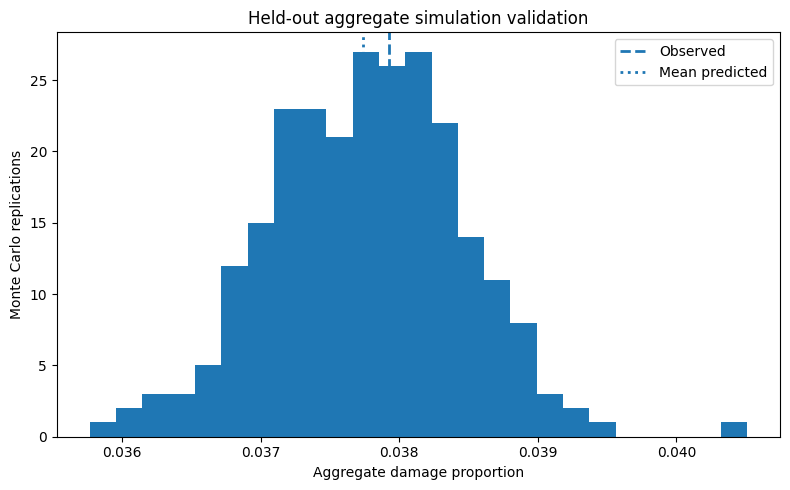

observed_minus_expected                      0.000192
absolute_difference_percentage_points        0.019228
observed_inside_95pct_simulation_interval        True
dtype: object

In [16]:
heldout_X=heldout[DAMAGE_FEATURES]; heldout_y=heldout["INDICATED_DAMAGE"].astype(int).to_numpy(); heldout_p=damage_model.predict_proba(heldout_X)[:,1]
heldout_metrics=pd.Series({"n":len(heldout_y),"observed_damage_rate":heldout_y.mean(),"mean_predicted_probability":heldout_p.mean(),"brier":brier_score_loss(heldout_y,heldout_p),"log_loss":log_loss(heldout_y,heldout_p,labels=[0,1])}); display(heldout_metrics)

rng=np.random.default_rng(SEED); R=250; aggregate_rates=np.array([rng.binomial(1,heldout_p).mean() for _ in range(R)])
agg=pd.Series({"replications":R,"simulated_mean":aggregate_rates.mean(),"simulated_sd":aggregate_rates.std(ddof=1),"q025":np.quantile(aggregate_rates,.025),"q975":np.quantile(aggregate_rates,.975),"observed_rate":heldout_y.mean(),"mean_model_probability":heldout_p.mean()}); display(agg); agg.to_csv(OUTPUT_DIR/"heldout_aggregate_validation.csv")
fig,ax=plt.subplots(figsize=(8,5)); ax.hist(aggregate_rates,bins=25); ax.axvline(heldout_y.mean(),linestyle="--",linewidth=2,label="Observed"); ax.axvline(heldout_p.mean(),linestyle=":",linewidth=2,label="Mean predicted"); ax.set_xlabel("Aggregate damage proportion"); ax.set_ylabel("Monte Carlo replications"); ax.set_title("Held-out aggregate simulation validation"); ax.legend(); plt.tight_layout(); plt.show()

observed_minus_expected = heldout_y.mean() - heldout_p.mean()

inside_mc_interval = (
    np.quantile(aggregate_rates, 0.025)
    <= heldout_y.mean()
    <= np.quantile(aggregate_rates, 0.975)
)

validation_decision = pd.Series({
    "observed_minus_expected": observed_minus_expected,
    "absolute_difference_percentage_points":
        abs(observed_minus_expected) * 100,
    "observed_inside_95pct_simulation_interval":
        inside_mc_interval,
})

display(validation_decision)
validation_decision.to_csv(
    OUTPUT_DIR / "heldout_validation_decision.csv"
)


### Held-out interpretation

The locked 2022–2024 population contained 59,219 wildlife-strike records and had an observed aircraft-damage rate of approximately 3.793%. The calibrated model assigned a mean predicted probability of approximately 3.774%, an absolute difference of only about 0.019 percentage points.

Across 250 aggregate Monte Carlo replications, the simulated mean damage rate was approximately 3.776%, with a 95% simulation interval from approximately 3.636% to 3.900%. The observed 3.793% rate falls inside this interval. The difference between observed and model-implied aggregate damage is therefore small relative to ordinary Monte Carlo sampling variability.

The held-out Brier score was approximately 0.0287 and log loss approximately 0.1129. Taken together, these results support the calibrated binary probability system as a coherent Monte Carlo backbone at the aggregate level on genuinely later data. This does not imply deterministic prediction of individual strike outcomes, and the simulation definition is not changed after observing this test result.

## 15. Three uncertainty sources

### Monte Carlo sampling variability
Finite random draws after probabilities are fixed. This decreases approximately as $O(N^{-1/2})$.

### Model uncertainty
The probabilities are estimates learned from historical data. Ordinary Monte Carlo draws do not automatically include finite-sample, model-family, calibration, drift, or unseen-airport uncertainty.

### Data/support uncertainty
A scenario may have few or no historical analogues.

Increasing trials reduces only the first source. It cannot repair weak model generalization or sparse historical support.

In [17]:
def support_label(n, relaxed=False):
    if n==0: return "UNSUPPORTED"
    label="VERY_LOW" if n<25 else "LOW" if n<100 else "MODERATE" if n<500 else "STRONG"
    return label + ("_DONOR_RELAXED" if relaxed else "")
print("Example support:",support_label(example_summary["support"]["exact_support"],example_summary["support"]["relaxed"]))

Example support: STRONG


The support bands are descriptive interface aids, not calibrated confidence intervals. Probability and historical support should be shown separately.

## 16. Sensitivity to empirical filling

Repeating the donor fill with several seeds separates variability from unspecified scenario context from the later Bernoulli outcome draw.

In [18]:
rows=[]
for seed in [7,42,99,314,2026,9001]:
    X,s=build_simulation_rows(EXAMPLE_SCENARIO,DEFAULT_TRIALS,seed); p=damage_model.predict_proba(X[DAMAGE_FEATURES])[:,1]
    rows.append({"seed":seed,"mean_probability":p.mean(),"sd_across_rows":p.std(ddof=1),"q05":np.quantile(p,.05),"q50":np.quantile(p,.5),"q95":np.quantile(p,.95),"exact_support":s["exact_support"],"donor_support":s["donor_support"],"strategy":s["strategy"]})
filling_sensitivity=pd.DataFrame(rows); display(filling_sensitivity); filling_sensitivity.to_csv(OUTPUT_DIR/"empirical_filling_sensitivity.csv",index=False)

,seed,mean_probability,sd_across_rows,q05,q50,q95,exact_support,donor_support,strategy
0,7,0.028333,0.047532,0.0,0.017831,0.086022,1053,1053,exact_user_specification
1,42,0.028596,0.047029,0.0,0.017831,0.110891,1053,1053,exact_user_specification
2,99,0.029062,0.046884,0.0,0.017831,0.110891,1053,1053,exact_user_specification
3,314,0.030037,0.049648,0.0,0.017831,0.110891,1053,1053,exact_user_specification
4,2026,0.027999,0.046695,0.0,0.017831,0.086022,1053,1053,exact_user_specification
5,9001,0.028571,0.045998,0.0,0.017831,0.110891,1053,1053,exact_user_specification


### Empirical-filling interpretation

The hybrid scenario estimate was stable across repeated empirical donor samples. Across six random seeds, the mean calibrated damage probability ranged from approximately 2.80% to 3.00%, with all runs using the same 1,053-record exact donor population and requiring no relaxation.

The median trial-level probability remained approximately 1.78% across all seeds, while the 95th percentile was generally between approximately 8.60% and 11.09%. The within-scenario standard deviation of individual probabilities was much larger than the variation in the mean across seeds. This indicates that the unspecified contextual variables create genuine heterogeneity among individual simulated strike conditions, while the aggregate scenario estimate remains comparatively stable.

Therefore, empirical filling appears suitable for optional scenario fields in the planned interface. The dashboard should nevertheless make clear that a partially specified scenario represents a distribution over historically compatible conditions rather than a single fully fixed aircraft-strike state.

## 17. Fully specified mode and single-trial export

Fully specified scenarios are useful for isolating a model response to one changed field. One representative trial can also be exported for visualization, but the aggregate distribution remains the scientific result.

In [19]:
def full_scenario_from_row(row): return {f:row[f] for f in DAMAGE_FEATURES}
complete=dev_reference.dropna(subset=DAMAGE_FEATURES)
fully_specified_example=full_scenario_from_row(complete.sample(1,random_state=SEED).iloc[0]) if len(complete) else None

def representative_trial(results, seed=SEED):
    row=results.iloc[int(np.random.default_rng(seed).integers(0,len(results)))]; fields=["trial","p_damage","damage","severity_known_draw"]+[t.lower() for t in component_systems]; out={}
    for f in fields:
        if f in row.index:
            v=row[f]
            if pd.isna(v): v=None
            elif hasattr(v,"item"): v=v.item()
            out[f]=v
    return out
example_trial=representative_trial(example_trials); print(json.dumps(example_trial,indent=2,default=str))

{
  "trial": 892,
  "p_damage": 0.1928934007883072,
  "damage": 0,
  "severity_known_draw": null,
  "engine_damage": 0,
  "forward_cockpit_damage": 0,
  "landing_gear_damage": 0,
  "propeller_damage": 0,
  "wing_rotor_damage": 0
}


## 18. Streamlit-facing exports

The interface should reuse this scenario contract, restrict choices to historically represented values, show support before simulation, and show aggregate results before any illustrative trial.

In [20]:
def allowed_values(frame,fields): return {f:frame[f].dropna().astype(str).value_counts().index.tolist() for f in fields if f in frame}
schema={"required_fields":REQUIRED_USER_FIELDS,"geography_one_of":GEOGRAPHY_FIELDS,"optional_fields":OPTIONAL_USER_FIELDS,"allowed_values":allowed_values(dev_reference,REQUIRED_USER_FIELDS+GEOGRAPHY_FIELDS+OPTIONAL_USER_FIELDS),"default_trials":DEFAULT_TRIALS,"support_reference_period":"1990-2021","scope":"Consequences conditional on a wildlife strike; not strike occurrence."}
(OUTPUT_DIR/"scenario_input_schema.json").write_text(json.dumps(schema,indent=2,default=str),encoding="utf-8")
(OUTPUT_DIR/"example_scenario.json").write_text(json.dumps(EXAMPLE_SCENARIO,indent=2,default=str),encoding="utf-8")
(OUTPUT_DIR/"example_trial.json").write_text(json.dumps(example_trial,indent=2,default=str),encoding="utf-8")
print("Exported Streamlit-facing JSON files")

Exported Streamlit-facing JSON files


## 19. Reproducibility audit

Before completion, restart the kernel and run all cells in order. Confirm portable paths, no model retraining, same-seed reproducibility, stable aggregate conclusions across different seeds, and clean regeneration of exported files.

In [21]:
_,a=run_monte_carlo(EXAMPLE_SCENARIO,1000,123,False,False); _,b=run_monte_carlo(EXAMPLE_SCENARIO,1000,123,False,False)
assert a["simulated_damage_rate"]==b["simulated_damage_rate"]
assert a["damage_probability_mean"]==b["damage_probability_mean"]
print("Same-seed reproducibility check passed")

Same-seed reproducibility check passed


## 20. Final interpretation placeholders

### Primary simulation conclusion
The calibrated binary probability system produced stable and internally coherent aggregate consequence distributions. For the strongly supported demonstration scenario, the mean fitted damage probability was approximately 2.86% and the 10,000-trial simulated damage rate was approximately 2.91%. Same-seed reproducibility also passed, confirming that the simulation can be reproduced exactly when the random state and scenario are fixed. The binary probability model is therefore suitable as the primary Monte Carlo backbone, subject to the previously identified model- and support-related limitations.

### Convergence and runtime
The convergence analysis supports retaining 10,000 trials as the default. Seed-to-seed variability declined materially as trial count increased, reaching a standard deviation of approximately 0.00176 at 10,000 trials. Mean binary simulation runtime remained below one second at this scale, and the complete consequence simulation required only approximately one second. Increasing the default substantially beyond 10,000 would therefore provide relatively limited practical benefit compared with the remaining model and support uncertainty.

### Hybrid-input behaviour
Empirical filling of unspecified context introduced substantial variation among individual trial probabilities but little instability in the aggregate scenario estimate. Across donor-sampling seeds, the mean probability remained within approximately 2.80%–3.00%, while individual trial probabilities were more widely dispersed. The hybrid approach therefore captures uncertainty about unspecified flight and wildlife context without making the aggregate result excessively sensitive to the random donor sample.

### Severity
Among the 291 simulated strikes in which aircraft damage occurred, approximately 77.0% of the known-severity draws were Minor and 23.0% were Substantial/Destroyed. These percentages must be interpreted conditional on both simulated aircraft damage and severity being determined. They do not describe all wildlife strikes, and they do not assign a physical severity to the excluded `M?` category.

### Components and co-occurrence
Conditional on simulated aircraft damage, the demonstration scenario produced marginal component involvement rates of approximately 9.6% for engine damage, 33.3% for forward-cockpit damage, 2.4% for landing-gear damage, 0% for propeller damage in this particular draw, and 25.8% for wing/rotor damage.

The observed component data contained substantially more pairwise dependence than the independently sampled simulation. Mean absolute pairwise $ϕ$ was approximately 0.126 in the observed damaged records versus 0.047 in the simulated outcomes. Therefore, the component models are retained for marginal probability communication, but exact multi-component combinations should not be presented as validated joint physical consequences. Propeller damage must retain its lower-support warning. This interpretation is consistent with the upstream requirement that independent component probability models not be treated as a complete dependence or physical-propagation model.

### Controlled comparison
Holding the contextual donor sample constant, the mean calibrated damage probability increased from approximately 0.80% for Small wildlife to 3.78% for Medium wildlife and 15.45% for Large wildlife. The resulting increases relative to Small wildlife were approximately 2.98 and 14.65 percentage points respectively. The pattern is consistent with wildlife size being an important model input, but it remains a model-based conditional contrast rather than evidence of a causal effect. Historical support also decreases substantially for Large wildlife, with only 48 exact records compared with 417 and 456 for Small and Medium wildlife.

### Held-out validation
The observed 2022–2024 damage rate was approximately 3.793%, compared with a mean model probability of approximately 3.774% and a mean simulated rate of approximately 3.776%. The observed rate lies within the Monte Carlo 95% interval of approximately 3.636%–3.900%, and the observed-to-expected difference is only about 0.019 percentage points. This provides strong aggregate evidence that the locked calibrated probability model and Monte Carlo sampling mechanism remain coherent on the final temporal holdout.

### Historical support
Historical support is treated separately from predicted probability. The main KMEM/Heavy/Autumn/Approach demonstration has 1,053 exact development/reference records and is therefore classified as strongly supported, with no donor relaxation required. In the wildlife-size comparison, Small and Medium wildlife retain moderate support with 417 and 456 exact records respectively, while Large wildlife has only 48 records and should receive a low-support warning. Zero-support combinations remain blocked rather than assigned potentially misleading probability estimates. These support labels are descriptive communication aids rather than calibrated confidence intervals.

## 21. Limitations

- Results are conditional on a wildlife strike and cannot estimate ordinary-flight strike probability.
- This is not a physical impact, aerodynamic, or structural simulator.
- More trials reduce Monte Carlo noise but do not eliminate model or support uncertainty.
- Airport identity can reflect ecology, operations, traffic mix, geography and reporting practices simultaneously.
- Hybrid scenarios depend on historical donor records and require warnings when support is sparse.
- Known-severity simulation excludes `M?` and applies only when severity is determined.
- Component models were fitted independently; marginal probabilities are stronger claims than exact joint component bundles.
- Propeller damage remains a lower-support retained component.
- The supplied analytical extract ends in 2024; there is no unused 2025+ holdout in this file.
- Serialized model artifacts require compatible software versions for faithful reproduction.

## 22. Streamlit handoff

Notebook 10 establishes the locked probability source, hybrid scenario builder, support diagnostics, Monte Carlo engine, approved severity/component layers, convergence checks, controlled comparisons, component co-occurrence diagnostics, held-out aggregate validation, and interface-facing JSON/CSV outputs.

The Streamlit application should reuse this logic instead of creating a second simulation definition.

## 23. References

- Federal Aviation Administration. *National Wildlife Strike Database* and associated documentation.
- Kroese, D. P., Brereton, T., Taimre, T., & Botev, Z. I. (2014). Why the Monte Carlo method is so important today. *WIREs Computational Statistics, 6*(6), 386–392.
- Gneiting, T., & Raftery, A. E. (2007). Strictly proper scoring rules, prediction, and estimation. *Journal of the American Statistical Association, 102*(477), 359–378.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of ICML*.
- Approved project probability artifacts from the calibration/validation, severity, component, and explainability stages.

All outputs are historical, model-based probabilities for defined strike scenarios and do not replace operational aviation guidance or engineering inspection.